## Task

With what accuracy can breast cancer be predicted using Logistic Regression? Proceed as follows:

1. Classify whether the tumor is benign or malignant on the basis of all measured variables.
1. Investigate the influence of normalization of data by means of mean exemption and scaling on unit variance.
1. Classify the diagnosis based on each feature.
1. Use the features you identified in the box-whiskers plot task to classify.
1. Experiment with different combinations of features.
1. Visualize and compare the Accuracies for each classification.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv('https://raw.githubusercontent.com/mGalarnyk/'
                 + 'Python_Tutorials/master/Kaggle/BreastCancerWisconsin/data/data.csv')
df = df.drop(columns=["id","Unnamed: 32"], axis = 1)

In [2]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Diagnosis কলামকে ম্যাপ করা (Malignant = 1, Benign = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# X (সবগুলো ফিচার) এবং y (টার্গেট) আলাদা করা
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# ডাটা ভাগ করা
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# লজিস্টিক রিগ্রেশন মডেল
model_all = LogisticRegression(max_iter=10000)
model_all.fit(X_train, y_train)
acc_all = accuracy_score(y_test, model_all.predict(X_test))

print(f"Accuracy with all features: {acc_all:.4f}")

Accuracy with all features: 0.9561


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model_scaled = LogisticRegression()
model_scaled.fit(X_train_s, y_train_s)
acc_scaled = accuracy_score(y_test_s, model_scaled.predict(X_test_s))

print(f"Accuracy after scaling: {acc_scaled:.4f}")

Accuracy after scaling: 0.9737


In [5]:
feature_accuracies = {}

for col in X.columns:
    X_single = X[[col]]
    X_t, X_ts, y_t, y_ts = train_test_split(X_single, y, test_size=0.2, random_state=42)
    
    m = LogisticRegression()
    m.fit(X_t, y_t)
    feature_accuracies[col] = accuracy_score(y_ts, m.predict(X_ts))

# টপ ৩টি ফিচার দেখা
sorted_acc = sorted(feature_accuracies.items(), key=lambda x: x[1], reverse=True)
print("Top 3 individual features:", sorted_acc[:3])

Top 3 individual features: [('perimeter_worst', 0.9649122807017544), ('radius_worst', 0.9385964912280702), ('area_worst', 0.9385964912280702)]


In [9]:
# উদাহরণস্বরূপ ৩টি ফিচারের কম্বিনেশন
selected_features = ['perimeter_worst', 'radius_worst', 'area_worst'] 
X_sel = X[selected_features]

X_t_sel, X_ts_sel, y_t_sel, y_ts_sel = train_test_split(X_sel, y, test_size=0.2, random_state=42)
model_sel = LogisticRegression()
model_sel.fit(X_t_sel, y_t_sel)
acc_sel = accuracy_score(y_ts_sel, model_sel.predict(X_ts_sel))

print(f"Accuracy with selected features: {acc_sel:.4f}")

Accuracy with selected features: 0.9474


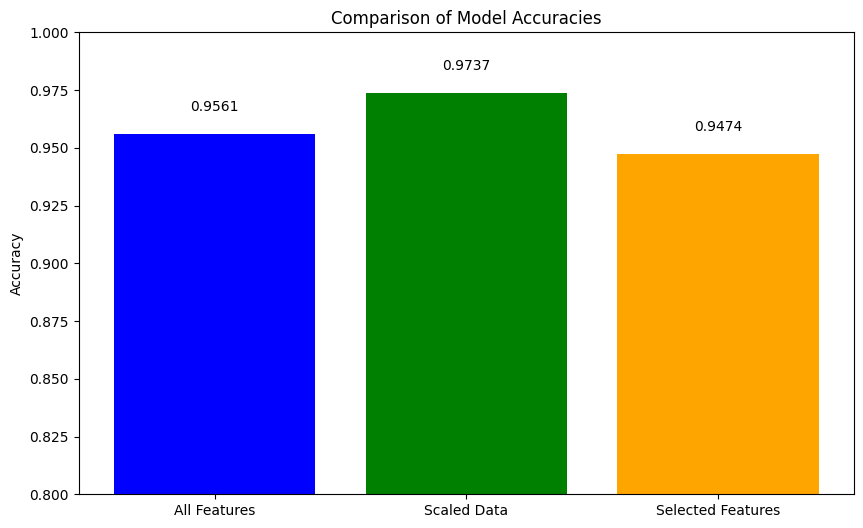

In [11]:
results = {
    'All Features': acc_all,
    'Scaled Data': acc_scaled,
    'Selected Features': acc_sel
}

plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange'])
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(0.8, 1.0) # গ্রাফটি ভালোমতো দেখার জন্য
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>